In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load the combined NHANES parquet
df = pd.read_parquet("../data/processed/nhanes_combined.parquet")

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()


Shape: (17846, 82)

Columns:
['participant_id', 'SDDSRVYR', 'RIDSTATR', 'sex', 'age', 'RIDRETH1', 'race_ethnicity', 'RIDEXMON', 'DMDBORN4', 'education', 'DMDMARTZ', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'WTINTPRP', 'WTMECPRP', 'SDMVPSU', 'SDMVSTRA', 'poverty_ratio', 'BMDSTATS', 'weight_kg', 'height_cm', 'bmi', 'BMXLEG', 'BMXARML', 'BMXARMC', 'waist_cm', 'BMXHIP', 'BPAOARM', 'BPAOCSZ', 'BPXOPLS1', 'BPXOPLS2', 'BPXOPLS3', 'total_cholesterol', 'LBDTCSI', 'hdl_cholesterol', 'LBDHDDSI', 'diagnosed_diabetes', 'DIQ160', 'DIQ180', 'DIQ070', 'hba1c', 'WTSAFPRP', 'fasting_glucose', 'LBDGLUSI', 'ever_smoked_100', 'SMD030', 'current_smoker', 'SMAQUEX2', 'vigorous_work_activity', 'moderate_work_activity', 'PAQ625', 'PAD630', 'PAQ635', 'PAQ650', 'PAQ665', 'PAQ670', 'PAD675', 'sedentary_minutes', 'cycle', 'DMQMILIZ', 'DMDHHSIZ', 'WTINT2YR', 'WTMEC2YR', 'WTPH2YR', 'WTPH2YR_hdl_cholesterol', 'WTPH2YR_hba1c', 'PAD790Q', 'PAD7

,participant_id,SDDSRVYR,RIDSTATR,sex,age,RIDRETH1,race_ethnicity,RIDEXMON,DMDBORN4,education,...,WTPH2YR_hdl_cholesterol,WTPH2YR_hba1c,PAD790Q,PAD790U,PAD800,PAD810Q,PAD810U,PAD820,sbp,dbp
0,109266,66.0,2.0,F,29.0,5.0,6.0,2.0,2.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.0,53.5
1,109267,66.0,1.0,F,21.0,2.0,2.0,NaN,2.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,109268,66.0,1.0,F,18.0,3.0,3.0,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109271,66.0,2.0,M,49.0,3.0,3.0,2.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,109.5,68.0
4,109273,66.0,2.0,M,36.0,3.0,3.0,2.0,1.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112.5,67.0


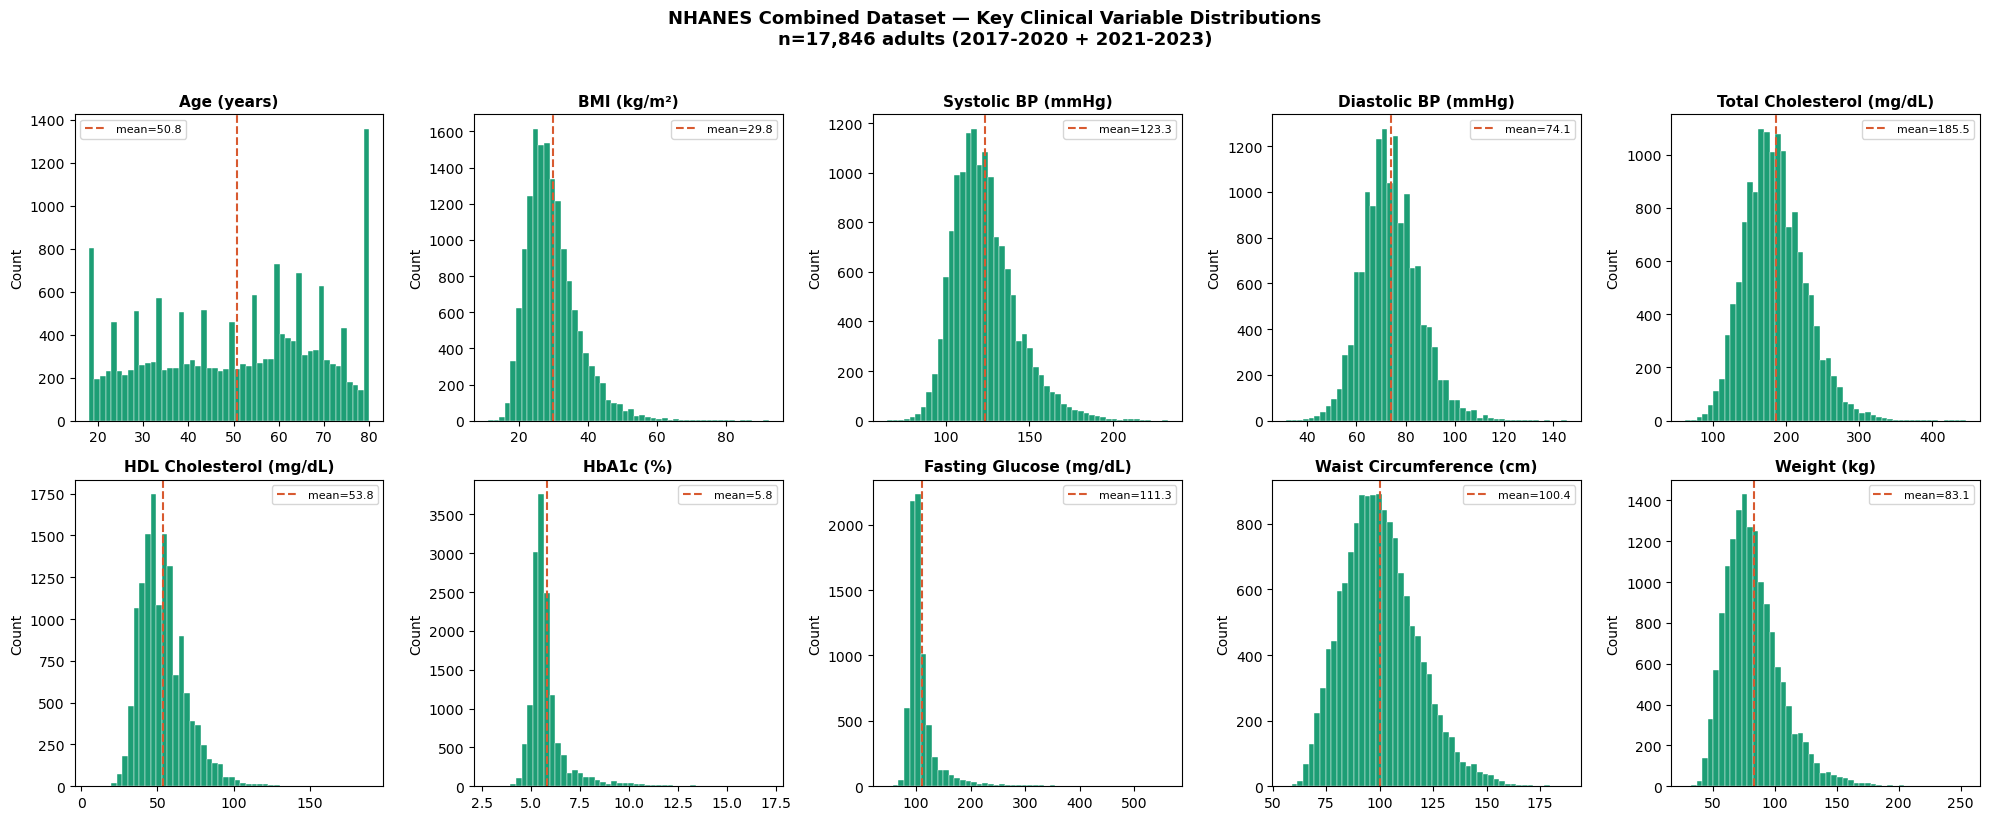

Saved to outputs/figures/nhanes_distributions.png


In [4]:
# Plot distributions of all key clinical variables
key_vars = {
    "age":               "Age (years)",
    "bmi":               "BMI (kg/m²)",
    "sbp":               "Systolic BP (mmHg)",
    "dbp":               "Diastolic BP (mmHg)",
    "total_cholesterol": "Total Cholesterol (mg/dL)",
    "hdl_cholesterol":   "HDL Cholesterol (mg/dL)",
    "hba1c":             "HbA1c (%)",
    "fasting_glucose":   "Fasting Glucose (mg/dL)",
    "waist_cm":          "Waist Circumference (cm)",
    "weight_kg":         "Weight (kg)",
}

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (var, label) in enumerate(key_vars.items()):
    data = df[var].dropna()
    axes[i].hist(data, bins=50, color="#1D9E75", edgecolor="white", linewidth=0.3)
    axes[i].set_title(label, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].axvline(data.mean(), color="#D85A30", linewidth=1.5,
                    linestyle="--", label=f"mean={data.mean():.1f}")
    axes[i].legend(fontsize=8)

plt.suptitle("NHANES Combined Dataset — Key Clinical Variable Distributions\n"
             f"n={len(df):,} adults (2017-2020 + 2021-2023)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/nhanes_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/figures/nhanes_distributions.png")

/var/folders/sj/zj39vrtj0sx5w_1vzy6s9s9h0000gp/T/ipykernel_45897/3347551072.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(bmi_by_race, labels=race_order, vert=True)
/var/folders/sj/zj39vrtj0sx5w_1vzy6s9s9h0000gp/T/ipykernel_45897/3347551072.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(sbp_by_race, labels=race_order, vert=True)


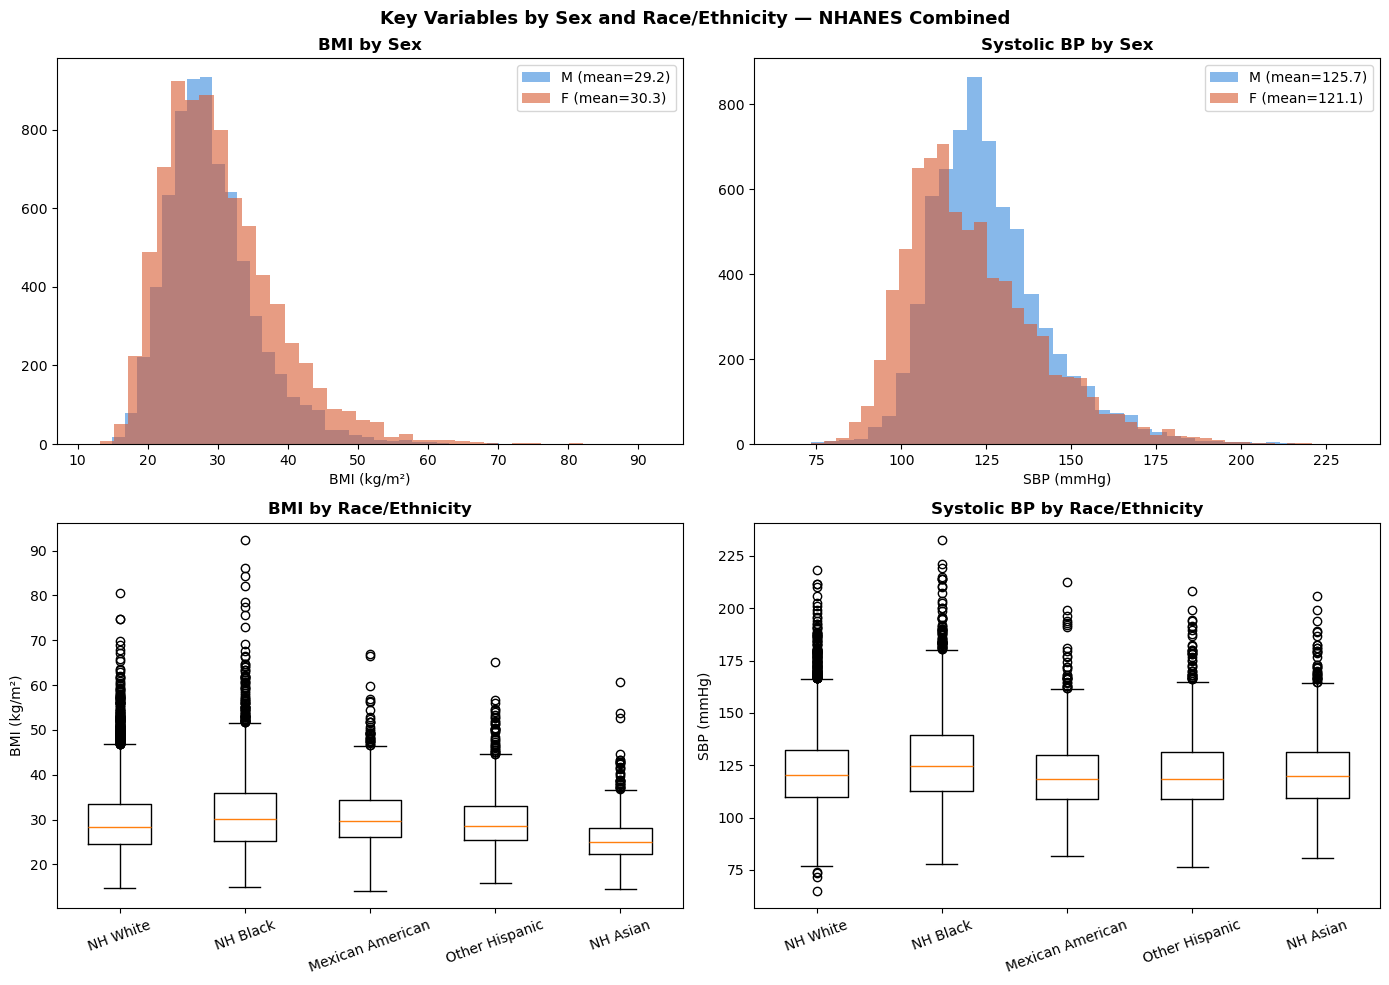

In [5]:
# BMI and SBP by sex and race — check for expected disparities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

race_map = {
    1.0: "Mexican American",
    2.0: "Other Hispanic",
    3.0: "NH White",
    4.0: "NH Black",
    6.0: "NH Asian",
    7.0: "Other/Multiracial"
}
df["race_label"] = df["race_ethnicity"].map(race_map)

# BMI by sex
for sex, color in [("M", "#378ADD"), ("F", "#D85A30")]:
    subset = df[df["sex"] == sex]["bmi"].dropna()
    axes[0,0].hist(subset, bins=40, alpha=0.6, color=color,
                   label=f"{sex} (mean={subset.mean():.1f})")
axes[0,0].set_title("BMI by Sex", fontweight="bold")
axes[0,0].set_xlabel("BMI (kg/m²)")
axes[0,0].legend()

# SBP by sex
for sex, color in [("M", "#378ADD"), ("F", "#D85A30")]:
    subset = df[df["sex"] == sex]["sbp"].dropna()
    axes[0,1].hist(subset, bins=40, alpha=0.6, color=color,
                   label=f"{sex} (mean={subset.mean():.1f})")
axes[0,1].set_title("Systolic BP by Sex", fontweight="bold")
axes[0,1].set_xlabel("SBP (mmHg)")
axes[0,1].legend()

# BMI by race
race_order = ["NH White","NH Black","Mexican American","Other Hispanic","NH Asian"]
bmi_by_race = [df[df["race_label"]==r]["bmi"].dropna() for r in race_order]
axes[1,0].boxplot(bmi_by_race, labels=race_order, vert=True)
axes[1,0].set_title("BMI by Race/Ethnicity", fontweight="bold")
axes[1,0].set_ylabel("BMI (kg/m²)")
axes[1,0].tick_params(axis='x', rotation=20)

# SBP by race
sbp_by_race = [df[df["race_label"]==r]["sbp"].dropna() for r in race_order]
axes[1,1].boxplot(sbp_by_race, labels=race_order, vert=True)
axes[1,1].set_title("Systolic BP by Race/Ethnicity", fontweight="bold")
axes[1,1].set_ylabel("SBP (mmHg)")
axes[1,1].tick_params(axis='x', rotation=20)

plt.suptitle("Key Variables by Sex and Race/Ethnicity — NHANES Combined",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/nhanes_by_demographics.png",
            dpi=150, bbox_inches="tight")
plt.show()